# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


df = pd.read_csv('Employee_productivity.csv')

df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


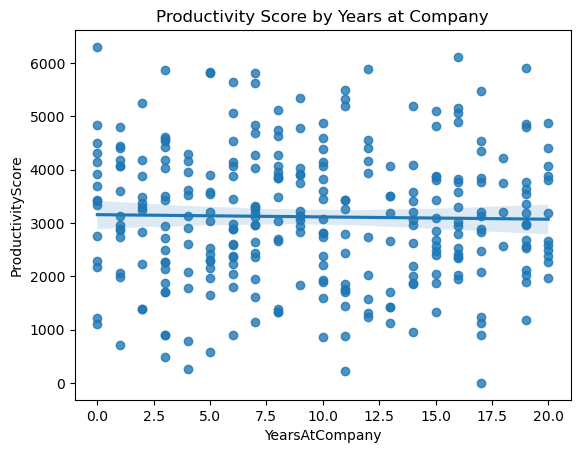

In [34]:
sns.regplot(x='YearsAtCompany', y='ProductivityScore', data=df)
plt.title('Productivity Score by Years at Company')
plt.show()

In [35]:
X = sm.add_constant(df['YearsAtCompany'])
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.1227
Date:                Wed, 10 Dec 2025   Prob (F-statistic):              0.726
Time:                        05:42:31   Log-Likelihood:                -2564.1
No. Observations:                 300   AIC:                             5132.
Df Residuals:                     298   BIC:                             5140.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3154.6734    136.338     23.139      0.000    2886.366    3422.981
YearsAtCompany    -4.2493     12.132     -0.350      0.726     -28.124      19.625
==============================================================================
Omnibus:                        2.338   Durbin-Watson:                   1.945
Prob(Omnibus):                  0.311   Jarque-Bera (JB):                2.025
Skew:                           0.091   Prob(JB):                        0.363
Kurtosis:                       2.641   Cond. No.                         21.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

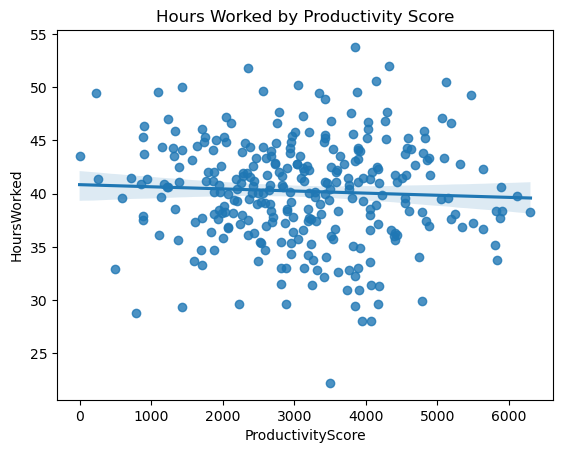

In [36]:
sns.regplot(x='ProductivityScore', y='HoursWorked', data=df)
plt.title('Hours Worked by Productivity Score')
plt.show()

In [37]:
X = sm.add_constant(df['ProductivityScore'])
y = df['HoursWorked']

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            HoursWorked   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7768
Date:                Wed, 10 Dec 2025   Prob (F-statistic):              0.379
Time:                        05:42:31   Log-Likelihood:                -900.65
No. Observations:                 300   AIC:                             1805.
Df Residuals:                     298   BIC:                             1813.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                40.8466      0.759     53.799      0.000      39.352      42.341
ProductivityScore    -0.0002      0.000     -0.881      0.379      -0.001       0.000
==============================================================================
Omnibus:                        4.154   Durbin-Watson:                   2.157
Prob(Omnibus):                  0.125   Jarque-Bera (JB):                3.925
Skew:                          -0.220   Prob(JB):                        0.141
Kurtosis:                       3.348   Cond. No.                     9.03e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.03e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

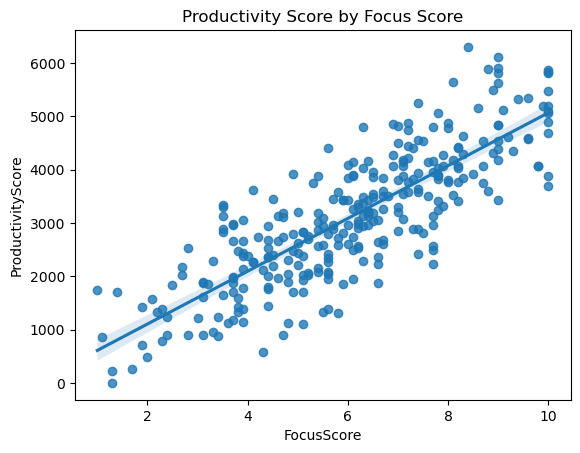

In [38]:
sns.regplot(x='FocusScore', y='ProductivityScore', data=df)
plt.title('Productivity Score by Focus Score')
plt.show()

In [39]:
X = sm.add_constant(df['FocusScore'])
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     626.6
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           3.02e-75
Time:                        05:42:31   Log-Likelihood:                -2394.3
No. Observations:                 300   AIC:                             4793.
Df Residuals:                     298   BIC:                             4800.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        114.3813    126.657      0.903      0.367    -134.874     363.636
FocusScore   494.9319     19.772     25.032      0.000     456.021     533.843
==============================================================================
Omnibus:                        0.756   Durbin-Watson:                   2.057
Prob(Omnibus):                  0.685   Jarque-Bera (JB):                0.869
Skew:                           0.076   Prob(JB):                        0.648
Kurtosis:                       2.784   Cond. No.                         20.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The Focus Score vs Productivity Score is by far the best regression fit. 

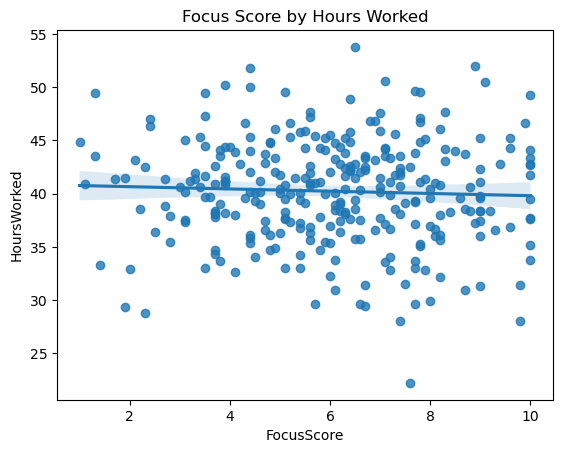

In [40]:
sns.regplot(x='FocusScore', y='HoursWorked', data=df)
plt.title('Focus Score by Hours Worked')
plt.show()

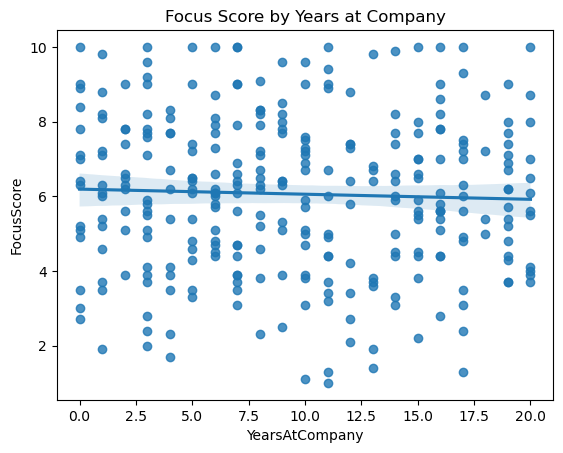

In [41]:
sns.regplot(x='YearsAtCompany', y='FocusScore', data=df)
plt.title('Focus Score by Years at Company')
plt.show()

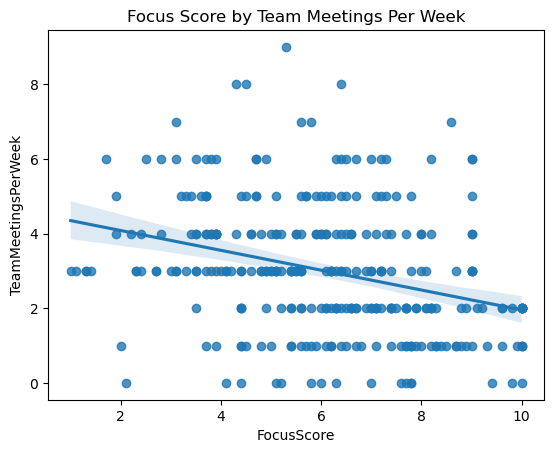

In [42]:
sns.regplot(x='FocusScore', y='TeamMeetingsPerWeek', data=df)
plt.title('Focus Score by Team Meetings Per Week')
plt.show()

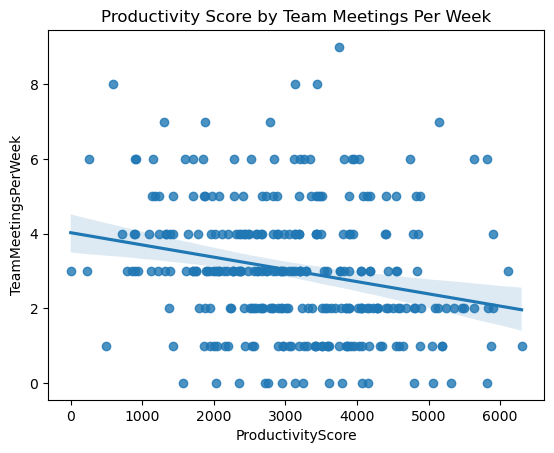

In [45]:
sns.regplot(x='ProductivityScore', y='TeamMeetingsPerWeek', data=df)
plt.title('Productivity Score by Team Meetings Per Week')
plt.show()

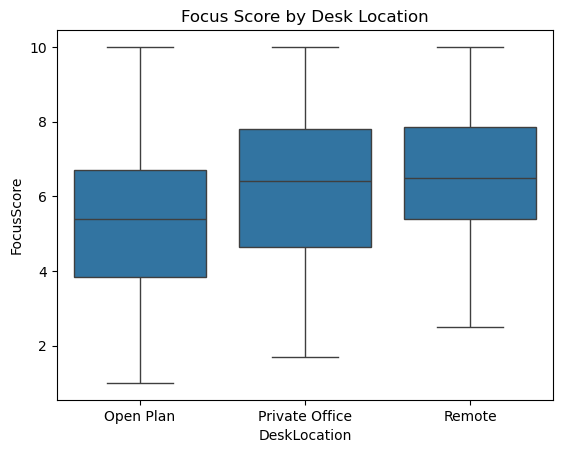

In [44]:
#Does DeskLocation impact ProductivityScore?
sns.boxplot(x='DeskLocation', y='FocusScore', data=df)
plt.title('Focus Score by Desk Location')
plt.show()

In [48]:
#Model a data point that would maximize ProductivityScore based on FocusScore, HoursWorked, TeamMeetingPerWeek, and YearsAtCompany.
X = sm.add_constant(df[['FocusScore', 'HoursWorked', 'TeamMeetingsPerWeek', 'YearsAtCompany']])
y = df['ProductivityScore'] 
model = sm.OLS(y, X).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     155.8
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           1.83e-71
Time:                        05:48:33   Log-Likelihood:                -2393.8
No. Observations:                 300   AIC:                             4798.
Df Residuals:                     295   BIC:                             4816.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 141.9005    390.827      0.363      0.717    -627.263     911.064
FocusScore            500.1073     20.937     23.886      0.000     458.902     541.313
HoursWorked            -3.5928      8.483     -0.424      0.672     -20.287      13.101
TeamMeetingsPerWeek    19.7534     24.717      0.799      0.425     -28.891      68.398
YearsAtCompany          2.7596      6.945      0.397      0.691     -10.909      16.428
==============================================================================
Omnibus:                        0.479   Durbin-Watson:                   2.052
Prob(Omnibus):                  0.787   Jarque-Bera (JB):                0.607
Skew:                           0.067   Prob(JB):                        0.738
Kurtosis:                       2.825   Cond. No.                         401.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

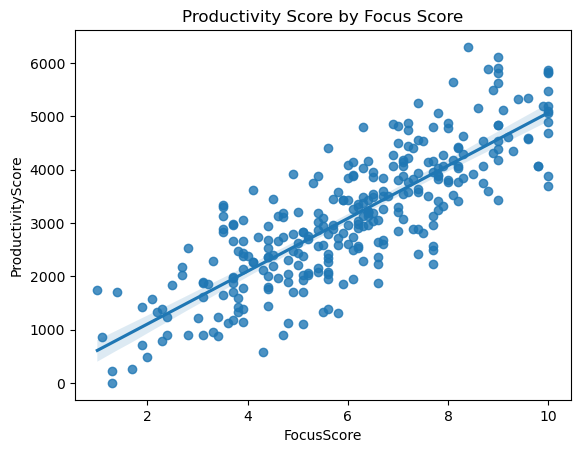

In [55]:
X = sm.add_constant(df[['FocusScore', 'YearsAtCompany']])
y = df['ProductivityScore'] 
model = sm.OLS(y, X).fit()
model.summary()

#plot the regression
sns.regplot(x='FocusScore', y='ProductivityScore', data=df)
plt.title('Productivity Score by Focus Score')
plt.show()

In [ ]:
X = sm.add_constant(df[['FocusScore', 'YearsAtCompany']])
y = df['ProductivityScore'] 
model = sm.OLS(y, X).fit()
model.summary()

#plot the regression
sns.regplot(x='FocusScore', y='ProductivityScore', data=df)
plt.title('Productivity Score by Focus Score')
plt.show()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     312.5
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           8.89e-74
Time:                        05:49:09   Log-Likelihood:                -2394.2
No. Observations:                 300   AIC:                             4794.
Df Residuals:                     297   BIC:                             4806.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             88.7215    145.130      0.611      0.541    -196.891     374.334
FocusScore       495.2145     19.816     24.990      0.000     456.217     534.212
YearsAtCompany     2.5120      6.904      0.364      0.716     -11.075      16.099
==============================================================================
Omnibus:                        0.768   Durbin-Watson:                   2.058
Prob(Omnibus):                  0.681   Jarque-Bera (JB):                0.883
Skew:                           0.082   Prob(JB):                        0.643
Kurtosis:                       2.791   Cond. No.                         44.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

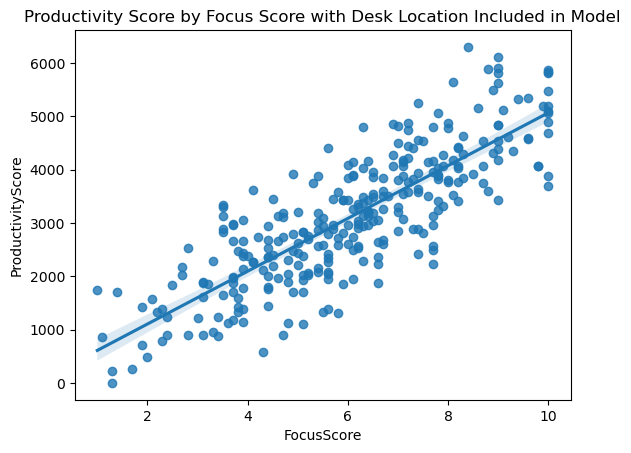

In [53]:
#Assign enum values for df[DeskLocation]
desk_location_mapping = {
    'Open Plan': 3,
    'Private Office': 2,
    'Remote': 1
}

df['DeskLocationEnum'] = df['DeskLocation'].map(desk_location_mapping)
X = sm.add_constant(df[['FocusScore', 'YearsAtCompany', 'DeskLocationEnum']])
y = df['ProductivityScore'] 
model = sm.OLS(y, X).fit()
model.summary()

#plot the regression results
sns.regplot(x='FocusScore', y='ProductivityScore', data=df)
plt.title('Productivity Score by Focus Score with Desk Location Included in Model')
plt.show()

In [54]:
desk_location_mapping = {
    'Open Plan': 3,
    'Private Office': 2,
    'Remote': 1
}

df['DeskLocationEnum'] = df['DeskLocation'].map(desk_location_mapping)
X = sm.add_constant(df[['FocusScore', 'YearsAtCompany', 'DeskLocationEnum']])
y = df['ProductivityScore'] 
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     211.6
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           2.58e-73
Time:                        05:57:45   Log-Likelihood:                -2392.3
No. Observations:                 300   AIC:                             4793.
Df Residuals:                     296   BIC:                             4807.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             -179.2233    198.230     -0.904      0.367    -569.342     210.895
FocusScore         504.6967     20.297     24.865      0.000     464.751     544.642
YearsAtCompany       2.3774      6.871      0.346      0.730     -11.145      15.900
DeskLocationEnum   103.6326     52.515      1.973      0.049       0.283     206.982
==============================================================================
Omnibus:                        0.620   Durbin-Watson:                   2.045
Prob(Omnibus):                  0.733   Jarque-Bera (JB):                0.733
Skew:                           0.045   Prob(JB):                        0.693
Kurtosis:                       2.775   Cond. No.                         62.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The R-squared model is almost the exact same when taking into account all the data categories vs just using FocusScore and YearsAtCompany. So the best approach is the simplist, FocusScore and YearsAtCompany are the best predictors of ProductivityScore.



UPDATE!!!: After converting the DeskLocations into an enum Value, I was able to include it in the R-squared model and found a better Regression fit. 